In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
Ulist = np.arange(0.2, 6.5, 0.1)
L = 30                         # 只计算L=30的系统
N=L*L                          #原胞数
alpha=0.1                      # 学习率（步长参数）

#动量空间基矢量，和三角晶格一样，晶格常数a=1
b1 = np.array([2*np.pi, -2*np.pi/1.7320508075688772])    # 对应sqrt(3)
b2 = np.array([0, 4*np.pi/1.7320508075688772])

#存储最终结果（收敛到基态）的数组，不参与运算，只用于储存和画图
#e_A_g = np.inf*np.ones(len(Ulist)) 
m_g = np.zeros((len(Ulist),3))        # 磁化强度m

qx_g = np.zeros((len(Ulist),3))       # 波矢Q的x分量
qy_g = np.zeros((len(Ulist),3))       # 波矢Q的y分量


In [6]:
#无相互作用能带记为e,是3带
e = np.zeros((3,L,L))
for nx in range(L):
    for ny in range(L):
        k=nx/L*b1+ny/L*b2
        kx=k[0]
        ky=k[1]
        f=np.cos(kx)+np.cos((kx+ky*np.sqrt(3))/2)+np.cos((-kx+ky*np.sqrt(3))/2)

        sqrt_val = np.sqrt(np.maximum(3 + 2*f, 0)) #防止因为浮点数精度导致负数开根号
        e[0,nx,ny] = -(1 + sqrt_val)
        e[1,nx,ny] = -(1 - sqrt_val)
        e[2,nx,ny]=2

#加上相互作用后，HF+自旋波,解出的能带，为6带，记作E
E=np.zeros((6,L,L))
#所有m和qx、qy做为参数出现在E即其梯度中，不占用数据结构维度
dEdm = np.zeros((6,L,L))   # 存储E对m的梯度在每个(k,能带)点的贡献
dEdqx = np.zeros((6,L,L))  # 存储E对qx的梯度在每个(k,能带)点的贡献  
dEdqy = np.zeros((6,L,L))  # 存储E对qy的梯度在每个(k,能带)点的贡献


In [7]:
# 记录总开始时间
total_start_time = time.time()
print(f"共{len(Ulist)}个U值，从{Ulist[0]}到{Ulist[-1]}")
for iU in range(len(Ulist)):
    U=Ulist[iU]

    # 记录每个U的开始时间
    U_start_time = time.time()
    print(f"\n U = {U:.2f} (第{iU+1}/{len(Ulist)}个)")
    
    m = 0.5/5 * U + 0.05 * np.random.random(3)   #随机初始化[mA,mB,mC]
    qx = 4*np.pi/3/5*U+0.05*np.random.random(3)  #随机初始化[qxA,qxB,qxC]
    qy = 4*np.pi/3/5*U+0.05*np.random.random(3)
    
    #初始化梯度下降更新长度
    diffm=np.ones(3);   maxdiffm=np.max(diffm)
    diffqx=np.ones(3);  maxdiffqx=np.max(diffqx)
    diffqy=np.ones(3);  maxdiffqy=np.max(diffqy) 

    ekq = np.zeros((3,L,L))
    dekqdqx = np.zeros((3,L,L))
    dekqdqy = np.zeros((3,L,L))

    itr = 0  # 添加迭代计数器

    while abs(maxdiffm)>10**-4 or abs(maxdiffqx)>10**-4 or abs(maxdiffqy)>10**-4:
        itr += 1
        
        # 每10次迭代打印一次进度
        if itr % 100 == 0:
            print(f"  U={U:.2f}: 第{itr}次迭代, diffm={maxdiffm:.6f}, diffqx={maxdiffqx:.6f}, diffqy={maxdiffqy:.6f}")

        for i in range(3):
            for nx in range(L):
                for ny in range(L):
                    k=nx/L*b1+ny/L*b2
                    kx=k[0]
                    ky=k[1]
                    f=np.cos(kx+qx[i])+np.cos((kx+qx[i]+(ky+qy[i])*np.sqrt(3))/2)+np.cos((-kx-qx[i]+(ky+qy[i])*np.sqrt(3))/2)
                    dfdqx=-np.sin(kx+qx[i])-np.sin((kx+qx[i]+(ky+qy[i])*np.sqrt(3))/2) /2+np.sin((-kx-qx[i]+(ky+qy[i])*np.sqrt(3))/2)/2
                    dfdqy=-np.sin((kx+qx[i]+(ky+qy[i])*np.sqrt(3))/2)*np.sqrt(3)/2-np.sin((-kx-qx[i]+(ky+qy[i])*np.sqrt(3))/2)*np.sqrt(3)/2                  
                    
                    sqrt_val = np.sqrt(np.maximum(3 + 2*f, 0))
                    if i==0:
                        ekq[i,nx,ny]=-(1+sqrt_val)              # eA(k+qA)
                        dekqdqx[i,nx,ny]=-1/sqrt_val*dfdqx      # ∂eA(k+qA)/∂qA_x
                        dekqdqy[i,nx,ny]=-1/sqrt_val*dfdqy      # ∂eA(k+qA)/∂qA_y
                    elif i==1:            
                        ekq[i,nx,ny]=-(1-sqrt_val)              # eB(k+qB)
                        dekqdqx[i,nx,ny]=1/sqrt_val*dfdqx       # ∂eB(k+qB)/∂qB_x
                        dekqdqy[i,nx,ny]=1/sqrt_val*dfdqy       # ∂eB(k+qB)/∂qB_y
                    else:                  
                        ekq[i,nx,ny]=2                                # eC(k+qC)          
                        dekqdqx[i,nx,ny]=0                            # ∂eC(k+qC)/∂qC_x
                        dekqdqy[i,nx,ny]=0                            # ∂eB(k+qC)/∂qC_y
        
        # 计算6个能带的本征值E
        # λ^±(k) = [ε(k)+ε(k+Q)]/2 ± √{[(ε(k)-ε(k+Q)]/2}^2 + (Um)^2
        # E={λA+ λB+ λC+ λA- λB- λC-}
        # 前三层：E[:3,:, :] or E[[0,1,2]:, :]

        mex=m.reshape(3, 1, 1) #不会覆盖m
        E[0:3,:,:] = (e+ekq)/2+np.sqrt(((e-ekq)/2)**2+U**2*mex**2) # +
        # 后三层: E[:, :, 3:] or E[:, :, [3,4,5]]
        E[3:6,:,:] = (e+ekq)/2-np.sqrt(((e-ekq)/2)**2+U**2*mex**2) # -  注意numpy广播的语法


        # 计算能量对m, qx, qy的梯度
        sqrt_term = np.sqrt((mex**2) * (U**2) + 0.25 * (e - ekq)**2)
        sqrt_term[sqrt_term == 0] = np.inf # 避免除以零

        # ∂E/∂q_x 的表达式（提前手动解析求导）
        dEdqx[:3,:,:] = ((0.5 - 0.25 * (e - ekq) / sqrt_term) * dekqdqx) / N
        dEdqx[3:,:,:] = ((0.5 + 0.25 * (e - ekq) / sqrt_term) * dekqdqx) / N
        # ∂E/∂q_y
        dEdqy[:3,:,:] = ((0.5 - 0.25 * (e - ekq) / sqrt_term) * dekqdqy) / N
        dEdqy[3:,:,:] = ((0.5 + 0.25 * (e - ekq) / sqrt_term) * dekqdqy) / N
        # ∂E/∂m
        dEdm[:3,:,:] = (U**2) * mex * (1 / sqrt_term) / N
        dEdm[3:,:,:] = -(U**2) * mex * (1 / sqrt_term) / N


        #展平数组，对所有6N个E(kx,ky)从小到大排序
        #E形状形状为 (a, b, c) 的数组，任意位置 E[i, j, k] 在 E.flatten() 中的索引index = i * (b * c) + j * c + k

        E_flat=E.flatten()  #形状(6N,)
        dEdqx_flat=dEdqx.flatten()
        dEdqy_flat=dEdqy.flatten()
        dEdm_flat=dEdm.flatten()

        #  np数组的“形状”比如(2,3,4)表示一个2层3行4列的np数组，每个元素的“索引”比如a[0,2,1]实际上是a[(0,2,1)]
        # 它们都是《元组》，是python固有数据类型，不是np的ndarray数组！！
        # 但1d数组的索引为了方便就是int类型

        # np.argsort() 以ndarray返回()内数组从小到大排序后的各索引(int类型）
        sorted_indices_flat = np.argsort(E_flat)    #为形状(6N,)的np数组！元素为E_flat的索引，数据类型为整数。
        #形状(6N,)和(6N,1)不一样。后者是货真价实的2d数组，尽管只有一行

        #  取前 4*N 个最小的E值对应的索引，，2/3填充只取前4N个
        occ_indices_flat = sorted_indices_flat[:4*N]

        #occ_indices=np.unravel_index(occ_indices_flat, E.shape) 
        # 使用 np.unravel_index 将一维索引转换为三维坐标
        # 只要使用flatten展平，np.unravel_index一定会按原来的行、列、层索引还原，不会打乱
        # 但np.unravel_index返回的是1d“元组”！len=4N，元素为ndarray
        
        dE_gdqx=np.zeros(3);dE_gdqy=np.zeros(3);dE_gdm=np.zeros(3)
        for i in range(6):
            for nx in range(L):
                for ny in range(L):
                    index=i*N+nx*L+ny
                    if index in occ_indices_flat:
                        if i==0 or i==3:
                            #∂E_g/∂qA_x
                            dE_gdqx[0]+=dEdqx_flat[index]        
                            dE_gdqy[0]+=dEdqy_flat[index]
                            dE_gdm[0]+=dEdm_flat[index]
                        elif i==1 or i==4:
                            #∂E_g/∂qB_x
                            dE_gdqx[1]+=dEdqx_flat[index]        
                            dE_gdqy[1]+=dEdqy_flat[index]
                            dE_gdm[1]+=dEdm_flat[index]
                        else :
                            #∂E_g/∂qC_x
                            dE_gdqx[2]+=dEdqx_flat[index]        
                            dE_gdqy[2]+=dEdqy_flat[index]
                            dE_gdm[2]+=dEdm_flat[index]
                    else: continue                   
        dE_gdm[0]+=2*U*m[0];dE_gdm[1]+=2*U*m[1];dE_gdm[2]+=2*U*m[2]

        for i in range(3):
            diffqx[i]=alpha*dE_gdqx[i] ; qx[i]-=diffqx[i]
            diffqy[i]=alpha*dE_gdqy[i] ; qy[i]-=diffqy[i]
            diffm[i]=alpha*dE_gdm[i] ; m[i]-=diffm[i]

        maxdiffm=np.max(diffm)
        maxdiffqx=np.max(diffqx)
        maxdiffqy=np.max(diffqy)
    
    # 记录每个U的结束时间
    U_end_time = time.time()
    U_elapsed = U_end_time - U_start_time
    print(f"完成 U = {U:.2f}: 迭代{itr}次, 耗时{U_elapsed:.2f}秒")
    print(f"  对应基态参数: m={m}, qx={qx}, qy={qy}")
    
    for i in range(3):
        m_g[iU][i]=m[i]
        qx_g[iU][i]=qx[i]
        qy_g[iU][i]=qy[i]


共63个U值，从0.2到6.400000000000002

 U = 0.20 (第1/63个)
完成 U = 0.20: 迭代78次, 耗时6.12秒
  对应基态参数: m=[0.00234394 0.00156843 0.00271827], qx=[0.20771992 0.17559963 0.18004566], qy=[0.18782363 0.18163804 0.2095323 ]

 U = 0.30 (第2/63个)
完成 U = 0.30: 迭代58次, 耗时4.60秒
  对应基态参数: m=[0.00153092 0.00144881 0.0018718 ], qx=[0.256135   0.27005056 0.27919999], qy=[0.29194853 0.29673095 0.25890633]

 U = 0.40 (第3/63个)
完成 U = 0.40: 迭代54次, 耗时4.24秒
  对应基态参数: m=[0.00046502 0.00112829 0.00130394], qx=[0.36441877 0.37146775 0.38380374], qy=[0.36124822 0.33960755 0.35180238]

 U = 0.50 (第4/63个)
完成 U = 0.50: 迭代46次, 耗时3.66秒
  对应基态参数: m=[0.00067318 0.00055188 0.00192665], qx=[0.45585043 0.44601841 0.4544148 ], qy=[0.42721252 0.45149619 0.46483237]

 U = 0.60 (第5/63个)
完成 U = 0.60: 迭代41次, 耗时3.30秒
  对应基态参数: m=[0.0005328  0.00069396 0.00115411], qx=[0.54443578 0.53321205 0.52148692], qy=[0.50627295 0.51701431 0.50934706]

 U = 0.70 (第6/63个)
  U=0.70: 第100次迭代, diffm=0.000000, diffqx=0.000112, diffqy=0.000149
  U=0.70: 第200次迭代

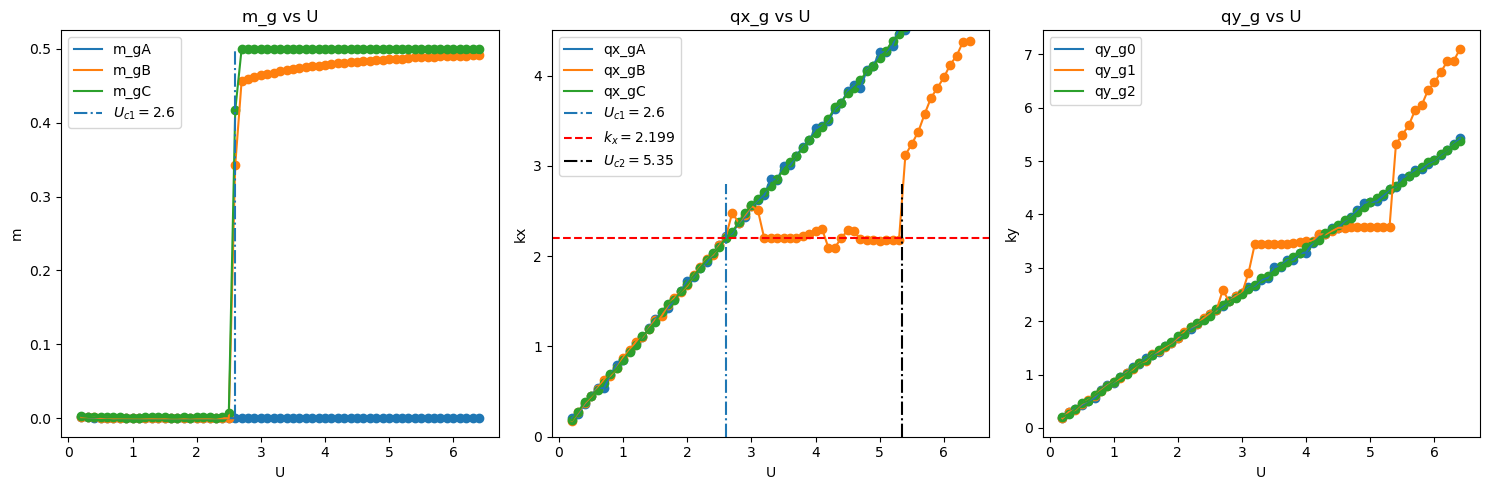

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# 第一张子图：m_g的三个分量
axs[0].plot(Ulist, m_g[:, 0], label='m_gA')
axs[0].scatter(Ulist, m_g[:, 0])
axs[0].plot(Ulist, m_g[:, 1], label='m_gB')
axs[0].scatter(Ulist, m_g[:, 1])
axs[0].plot(Ulist, m_g[:, 2], label='m_gC')
axs[0].scatter(Ulist, m_g[:, 2])
axs[0].vlines(2.6, 0, 0.5, linestyles='-.', label='$U_{c1} = 2.6$')
axs[0].set_xlabel('U')
axs[0].set_ylabel('m')
axs[0].set_title('m_g vs U')
axs[0].legend()

# 第二张子图：qx_g的三个分量
axs[1].plot(Ulist, qx_g[:, 0], label='qx_gA')
axs[1].scatter(Ulist, qx_g[:, 0])
axs[1].plot(Ulist, qx_g[:, 1], label='qx_gB')
axs[1].scatter(Ulist, qx_g[:, 1])
axs[1].plot(Ulist, qx_g[:, 2], label='qx_gC')
axs[1].scatter(Ulist, qx_g[:, 2])
axs[1].vlines(2.6, 0, 2.8, linestyles='-.', label='$U_{c1} = 2.6$')
axs[1].axhline(y=2.199, color='red', linestyle='--', label=r'$k_x =2.199$')
axs[1].vlines(5.35, 0,2.8, color='black', linestyles='-.', label='$U_{c2} = 5.35$')
axs[1].set_xlabel('U')
axs[1].set_ylabel('kx')
axs[1].set_title('qx_g vs U')
axs[1].set_ylim(0, np.pi*(4/3+0.1))
axs[1].legend()

# 第三张子图：qy_g的三个分量
axs[2].plot(Ulist, qy_g[:, 0], label='qy_g0')
axs[2].scatter(Ulist, qy_g[:, 0])
axs[2].plot(Ulist, qy_g[:, 1], label='qy_g1')
axs[2].scatter(Ulist, qy_g[:, 1])
axs[2].plot(Ulist, qy_g[:, 2], label='qy_g2')
axs[2].scatter(Ulist, qy_g[:, 2])
axs[2].set_xlabel('U')
axs[2].set_ylabel('ky')
axs[2].set_title('qy_g vs U')
axs[1].set_ylim(0, np.pi*(4/3+0.1))
axs[2].legend()

plt.tight_layout()
plt.show()

In [22]:
import numpy as np

# 保存所有计算结果
np.savez('calculation_results.npz',
         Ulist=Ulist,
         m_g=m_g,
         qx_g=qx_g,
         qy_g=qy_g)

print("计算结果已保存到 calculation_results.npz")

计算结果已保存到 calculation_results.npz
